---
numbering: false
---
# 4.2. Linear Independence

## Introduction

There's an idea we used all throughout [Chapter 4.1](./01-span.ipynb) that we haven't given a name to.

### Definitions

:::{note} Definition: Linear Independence
A set of vectors $\color{#3d81f6}\vec v_1$, $\color{#3d81f6}\vec v_2$, ..., $\color{#3d81f6}\vec v_d$ is **linearly independent** if either of the following equivalent conditions hold:

1. None of the vectors can be written as a linear combination of the others.
1. The only way to create the zero vector as a linear combination of the vectors is if all the coefficients are zero. In other words, the only solution to

    $$a_1 {\color{#3d81f6}\vec v_1} + a_2 {\color{#3d81f6}\vec v_2} + \ldots + a_d {\color{#3d81f6}\vec v_d} = \vec 0$$

    is $a_1 = a_2 = \ldots = a_d = 0$.

If a set of vectors is not linearly independent, it is **linearly dependent**.
:::

Intuitively, if a set of vectors is linearly **dependent**, then **at least one** of the vectors is a linear combination of the others. If we think of vectors as building blocks, if a set of vectors is linearly dependent, then at least one of the building blocks is redundant, because you can create it from the other building blocks.

Equivalently, if a set of vectors is linearly **dependent**, there's a **non-trivial** linear combination of the vectors that equals the zero vector (by non-trivial, I mean that at least one of the coefficients is non-zero).

Why are these two conditions equivalent? Here's one way to see it. Suppose $\vec v_1 = \alpha \vec v_2 + \beta \vec v_3$, meaning that $\vec v_1$ can be written as a linear combination of $\vec v_2$ and $\vec v_3$. Rearranging the equation above gives us

$$\vec v_1 - \alpha \vec v_2 - \beta \vec v_3 = \vec 0$$

which shows us a non-trivial linear combination of $\vec v_1, \vec v_2, \vec v_3$ that gives $\vec 0$. The converse (reverse direction) is true too: if you start with a non-trivial linear combination of $\vec v_1, \vec v_2, \ldots, \vec v_d$ that gives $\vec 0$, then you can rearrange it to get $\vec v_1 = \text{some linear combination of } \vec v_2, \ldots, \vec v_d$.

### Examples

Let's look at several sets of vectors and comment on their linear independence (or lack thereof).

| Vectors | Linearly... | Why? |
| --- | --- | --- |
| $\begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix}, \begin{bmatrix} 2 \\ 1 \\ 5 \end{bmatrix}$ | **Independent** | Neither is a multiple of the other. |
| $\begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix}, \begin{bmatrix} 2 \\ 1 \\ 5 \end{bmatrix}, \begin{bmatrix} 5 \\ 2 \\ 10 \end{bmatrix}, \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}$ | **Dependent** | These vectors live in $\mathbb{R}^3$, which is a universe that only has 3 independent directions, so you only need 3 vectors to span it. Give 4 vectors, we can write at least one of them as a linear combination of the others. |
| $\begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix}, \begin{bmatrix} 2 \\ 1 \\ 5 \end{bmatrix}, \begin{bmatrix} 5 \\ 2 \\ 13 \end{bmatrix}$ | **Dependent** | $\text{first vector} + 2(\text{second vector}) = \text{third vector}$  |
| $\begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix}, \begin{bmatrix} 2 \\ 1 \\ 5 \end{bmatrix}, \begin{bmatrix} 5 \\ 2 \\ 10 \end{bmatrix}$ | **Independent** | The first two were already linearly independent from the first example, and we can't write the third as a linear combination of the first two. |

Note that if a set of vectors is linearly dependent, it doesn't mean that **every** vector in the set can be written as a linear combination of the others. It just means that there's at least one vector that can be written as a linear combination of the others. A good go-to example for this is the one below – $\color{orange} \vec v_1$ and $\color{#3d81f6} \vec v_2$ are scalar multiples of each other, making the entire set of three vectors linearly dependent, but $\color{#d81b60} \vec v_3$ is not a linear combination of $\color{orange} \vec v_1$ and $\color{#3d81f6} \vec v_2$.

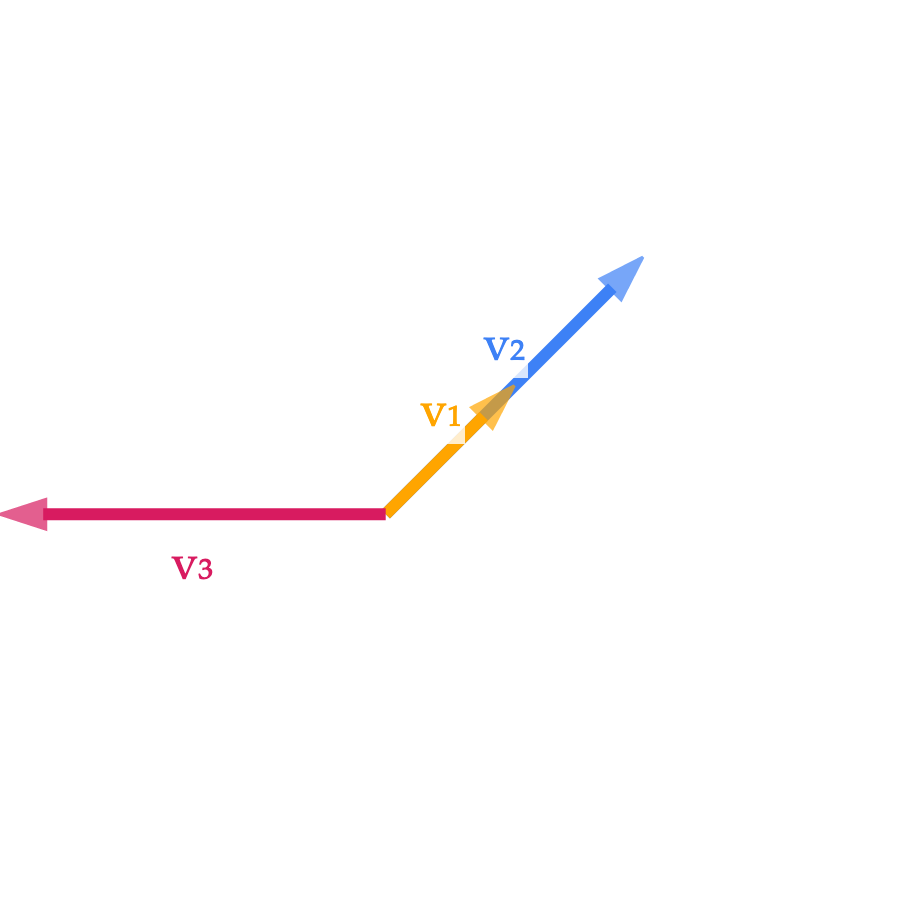

In [15]:
from utils import plot_vectors
import numpy as np

# Vectors
v1 = (1, 1)
v2_a = (2, 2)
v3 = (-3, 0)

# Common style for axes/layout
common_axis = dict(
    gridcolor="#f0f0f0",
    griddash="solid",
    showgrid=False,
    zeroline=False,
    zerolinecolor="#f0f0f0",
    zerolinewidth=1,
    constrain="domain",
    showticklabels=False,
    title_text=None,
)
common_layout = dict(
    xaxis_range=[-3, 4],
    yaxis_range=[-3, 4],
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Palatino",
    font_size=18,
)

# Plot just the left figure (v2_a)
fig = plot_vectors(
    [(v2_a, "#3d81f6", r"v₂"), (v1, "orange", r"v₁"), (v3, "#d81b60", r"v₃")],
    show_axis_labels=False,
    vdeltax=0.1,
    vdeltay=0.4
)
fig.update_xaxes(scaleanchor="y", scaleratio=1, **common_axis)
fig.update_yaxes(scaleanchor="x", scaleratio=1, **common_axis)
fig.update_layout(**common_layout, margin=dict(l=0, r=0, t=0, b=0))

fig.update_layout(width=300, height=300, showlegend=False, **common_layout)
fig.show(renderer="png", scale=3)


---

## Unique Linear Combinations

**Fact**: If a set of vectors ${\color{#3d81f6}\vec v_1}, {\color{#3d81f6}\vec v_2}, \ldots, {\color{#3d81f6}\vec v_d} \in \mathbb{R}^n$ is linearly independent, then any vector $\vec b \in \mathbb{R}^n$ in the span of the vectors can be written as a **unique** linear combination of the vectors.

We've built intuition for this above; now let's give a formal proof. But first, note that the statement assumes that $\vec b \in \text{span}(\{{\color{#3d81f6}\vec v_1}, {\color{#3d81f6}\vec v_2}, \ldots, {\color{#3d81f6}\vec v_d}\})$ to begin with: it is not saying that if ${\color{#3d81f6}\vec v_1}, {\color{#3d81f6}\vec v_2}, \ldots, {\color{#3d81f6}\vec v_d} \in \mathbb{R}^n$ are linearly independent, then any $\vec b \in \mathbb{R}^n$ can be written as a linear combination of the vectors. That's **not** true. The vectors $\vec v_1 = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}$ and $\vec v_2 = \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}$ are linearly independent, but $\vec b = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$ is not a linear combination of the first two. Hopefully, the fact above is a little more clear now. (Re-read it again before proceeding to the next paragraph.)

Let's imagine an alternate universe where $\vec b \in \text{span}(\{{\color{#3d81f6}\vec v_1}, {\color{#3d81f6}\vec v_2}, \ldots, {\color{#3d81f6}\vec v_d}\})$ can be written as two different linear combinations of the vectors. (We're doing a proof by contradiction, if you're familiar with the idea.) In other words, suppose

$$a_1 {\color{#3d81f6}\vec v_1} + a_2 {\color{#3d81f6}\vec v_2} + \ldots + a_d {\color{#3d81f6}\vec v_d} = \vec b$$

**and**

$$c_1 {\color{#3d81f6}\vec v_1} + c_2 {\color{#3d81f6}\vec v_2} + \ldots + c_d {\color{#3d81f6}\vec v_d} = \vec b$$

and **not** all of the $a_i$ and $c_i$ are equal, meaning there's at least one $i$ such that $a_i \neq c_i$.

What happens if we subtract the two equations?

$$(a_1 - c_1) {\color{#3d81f6}\vec v_1} + (a_2 - c_2) {\color{#3d81f6}\vec v_2} + \ldots + (a_d - c_d) {\color{#3d81f6}\vec v_d} = \vec 0$$

Since ${\color{#3d81f6}\vec v_1}, {\color{#3d81f6}\vec v_2}, \ldots, {\color{#3d81f6}\vec v_d}$ are linearly independent, the only way this equation can hold is if all of the coefficients on the $\color{#3d81f6}\vec v_i$ are zero. In other words, we'd need

$$a_1 - c_1 = 0 \\ a_2 - c_2 = 0 \\ \ldots \\ a_d - c_d = 0$$

But if that's the case, then $a_i = c_i$ for all $i$, which contradicts our assumption that not all of the $a_i$ and $c_i$ are equal.

So, this means that it **can't** be the case that $\vec b$ can be written as two different linear combinations of the vectors. In other words, if $\vec b \in \text{span}(\{{\color{#3d81f6}\vec v_1}, {\color{#3d81f6}\vec v_2}, \ldots, {\color{#3d81f6}\vec v_d}\})$ and ${\color{#3d81f6}\vec v_1}, {\color{#3d81f6}\vec v_2}, \ldots, {\color{#3d81f6}\vec v_d}$ are linearly independent, then $\vec b$ can be written as a **unique** linear combination of the vectors.

Linearly independent vectors are desirable, since there's only one way to use them as building blocks to create any other vector in their span.

:::{tip} Activity 1
:class: dropdown

Suppose $\vec v_1, \vec v_2, \ldots, \vec v_d \in \mathbb{R}^n$ are an orthogonal set of vectors, meaning that for any $i \neq j$, $\vec v_i \cdot \vec v_j = 0$. (Assume that the vectors are non-zero.)

In Lab 5, you'll show that any vector $\vec b \in \text{span}(\{\vec v_1, \vec v_2, \ldots, \vec v_d\})$ can be written as a linear combination of the vectors by projecting $\vec b$ onto each of the vectors $\vec v_i$.

Here, **prove that the vectors $\vec v_1, \vec v_2, \ldots, \vec v_d$ are linearly independent**. By doing this, you are showing that orthogonality is a stronger condition than linear independence.

:::{seealso} Solution
:class: dropdown

In order for $\vec v_1, \vec v_2, \ldots, \vec v_d$ to be linearly independent, we need to show that the only solution to

$$a_1 \vec v_1 + a_2 \vec v_2 + \ldots + a_d \vec v_d = \vec 0$$

is $a_1 = a_2 = \ldots = a_d = 0$. Otherwise, there must exist some other non-zero solution for the $a_i$'s.

Let's start with the equation above and take the dot product of both sides with $\vec v_1$.

$$(a_1 \vec v_1 + a_2 \vec v_2 + \ldots + a_d \vec v_d) \cdot \vec v_1 = \vec 0 \cdot \vec v_1$$

This expands to

$$a_1 (\vec v_1 \cdot \vec v_1) + a_2 (\vec v_2 \cdot \vec v_1) + \ldots + a_d (\vec v_d \cdot \vec v_1) = 0$$

Since $\vec v_1, \vec v_2, \ldots, \vec v_d$ are orthogonal, we know that $\vec v_i \cdot \vec v_j = 0$ for all $i \neq j$. This means that the only non-zero term in the equation above is $a_1 (\vec v_1 \cdot \vec v_1)$. So, we're left with

$$a_1 (\vec v_1 \cdot \vec v_1) = 0$$

Since $\vec v_1$ is non-zero, we can divide both sides by $\vec v_1 \cdot \vec v_1$ to get $a_1 = 0$.

We can repeat this process for each of the vectors $\vec v_2, \ldots, \vec v_d$ to show that $a_2 = \ldots = a_d = 0$, meaning that the only solution to $a_1 \vec v_1 + a_2 \vec v_2 + \ldots + a_d \vec v_d = \vec 0$ is $a_1 = a_2 = \ldots = a_d = 0$, meaning that $\vec v_1, \vec v_2, \ldots, \vec v_d$ are linearly independent.
:::

---

## Algorithm for Finding Linearly Independent Subsets with the Same Span

Given a set of vectors $\vec v_1, \vec v_2, \ldots, \vec v_d \in \mathbb{R}^n$, we'd like to find a subset of the vectors that is **linearly independent and has the same span** as the original set of vectors. In [Chapter 4.3](./03-vector-spaces-basis-dimension.ipynb), we'll call this subset a **basis** for the span of the original set of vectors.

In other words, we'd like to "drop" the vectors that are linearly dependent on the others. For example, if we have 3 vectors in $\mathbb{R}^3$ and they span a plane, we can drop one of them and still span **the same** plane (not just any plane), because a plane is a 2-dimensional space, and you only need 2 vectors to span a plane.

In the example below, we can remove any one of the three vectors (which all point in different directions), and the span of the remaining two is still **the exact same plane**!

In [16]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v1 = (1, 1, 1)
v2 = (1, -2, -3)
v3 = (-3, 0, 1)

fig = plot_vectors([(v1, "orange", r"v₁"), 
                    (v2, "#3d81f6", r"v₂"),
                    (v3, "#d81b60", r"v₃"),
                    ], show_axis_labels=True, vdeltax=0.3, vdeltay=1)

# Add the plane spanned by v1 and v2
plane_extent = 30
num_points = 3

s_range = np.linspace(-plane_extent, plane_extent, num_points)
t_range = np.linspace(-plane_extent, plane_extent, num_points)
s_grid, t_grid = np.meshgrid(s_range, t_range)

plane_x = s_grid * v1[0] + t_grid * v2[0]
plane_y = s_grid * v1[1] + t_grid * v2[1]
plane_z = s_grid * v1[2] + t_grid * v2[2]

fig.add_trace(go.Surface(
    x=plane_x,
    y=plane_y,
    z=plane_z,
    opacity=0.8,
    colorscale=[[0, 'rgba(61,129,246,0.3)'], [1, 'rgba(61,129,246,0.3)']],
    showscale=False,
))

fig.update_xaxes(
    scaleanchor="y",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_layout(
    xaxis_range=[-10, 10],
    yaxis_range=[-10, 10],
    width=600,
    height=600,
    scene_camera=dict(
        eye=dict(x=-1.2, y=0.5, z=2)
    ),
)

fig.show()

Dropping any "unnecessary" vectors will give us the desirable property that any vector in the span of the original set of vectors can be written as a **unique** linear combination of the vectors in the subset. (Remember that this has a connection to finding optimal model parameters in linear regression – this is not just an arbitrary exercise in theory.)

One way to produce a linear independent subset is to execute the following algorithm:

```
given v_1, v_2, ..., v_d
initialize linearly independent set S = {v_1}
for i = 2 to d:
    if v_i is not a linear combination of S:
        add v_i to S
```

The vectors we add to `S` are a basis for the span of the original set of vectors. The number of vectors we're left with is the dimension of the span of the original set of vectors. Again, these are ideas we formalize in [Chapter 4.3](./03-vector-spaces-basis-dimension.ipynb).

Let's evaluate this algorithm on the following set of vectors:

$$\vec v_1 = \begin{bmatrix} 3 \\ 4 \\ 0 \end{bmatrix}, \quad \vec v_2 = \begin{bmatrix} 0 \\ 1 \\ 1 \end{bmatrix}, \quad \vec v_3 = \begin{bmatrix} -3 \\ -2 \\ 2 \end{bmatrix}, \quad \vec v_4 = \begin{bmatrix} 6 \\ 5 \\ -3 \end{bmatrix}, \quad \vec v_5 = \begin{bmatrix} 2 \\ 5 \\ 1 \end{bmatrix}$$

First, we start with $\color{orange} S = \{\vec v_1\}$.

- **Iteration 1 ($i = 2$)**: Is $\vec v_2$ a linear combination of the vectors in $S$?<br>No, since $\vec v_2$ is not a multiple of $\vec v_1$. The first components (3 in $\vec v_1$, 0 in $\vec v_2$) imply that if $\vec v_2$ were a multiple of $\vec v_1$ it'd need to be $0 \vec v_1$, but the other components of $\vec v_2$ are non-zero.<br><br>
**Outcome**: Add $\vec v_2$ to $S$. Now, $\color{orange} S = \{\vec v_1, \vec v_2\}$.<br><br>
- **Iteration 2 ($i = 3$)**: Is $\vec v_3$ a linear combination of the vectors in $S$?<br>To determine the answer, we need to try and find scalars $a_1$ and $a_2$ such that $a_1 \vec v_1 + a_2 \vec v_2 = \vec v_3$. 
    $$
    a_1 \begin{bmatrix} 3 \\ 4 \\ 0 \end{bmatrix} + a_2 \begin{bmatrix} 0 \\ 1 \\ 1 \end{bmatrix} = \begin{bmatrix} -3 \\ -2 \\ 2 \end{bmatrix}
    \implies
    \begin{cases}
    3a_1 + 0a_2 = -3 \\
    4a_1 + 1a_2 = -2 \\
    0a_1 + 1a_2 = 2
    \end{cases}
    $$
    The first equation implies $a_1 = -1$ and the third equation implies $a_2 = 2$. Plugging both into the second equation gives $4(-1) + 1(2) = -2$, which is consistent. This means that $\vec v_3 = - \vec v_1 + 2 \vec v_2$, so $\vec v_3$ is a linear combination of $\vec v_1$ and $\vec v_2$, and we should not add it to $S$. <br><br>
    **Outcome**: Leave $S$ unchanged. Now, $\color{orange} S = \{\vec v_1, \vec v_2\}$.<br><br>

- **Iteration 4 ($i = 4$)**: Is $\vec v_4$ a linear combination of the vectors in $S$?<br>To determine the answer, we need to try and find scalars $a_1$ and $a_2$ such that $a_1 \vec v_1 + a_2 \vec v_2 = \vec v_4$. 
    $$
    a_1 \begin{bmatrix} 3 \\ 4 \\ 0 \end{bmatrix} + a_2 \begin{bmatrix} 0 \\ 1 \\ 1 \end{bmatrix} = \begin{bmatrix} 6 \\ 5 \\ -3 \end{bmatrix}
    \implies
    \begin{cases}
    3a_1 + 0a_2 = 6 \\
    4a_1 + 1a_2 = 5 \\
    0a_1 + 1a_2 = -3
    \end{cases}
    $$
    Similarly, we see that $a_1 = 2$ (from the first equation) and $a_2 = -3$ (from the third equation) are consistent with the second equation. This means that $\vec v_4 = 2 \vec v_1 - 3 \vec v_2$, so $\vec v_4$ is a linear combination of $\vec v_1$ and $\vec v_2$, and we should not add it to $S$.<br><br>
    **Outcome**: Leave $S$ unchanged. Now, $\color{orange} S = \{\vec v_1, \vec v_2\}$.<br><br>
- **Iteration 5 ($i = 5$)**: Is $\vec v_5$ a linear combination of the vectors in $S$?<br>To determine the answer, we need to try and find scalars $a_1$ and $a_2$ such that $a_1 \vec v_1 + a_2 \vec v_2 = \vec v_5$. 
    $$
    a_1 \begin{bmatrix} 3 \\ 4 \\ 0 \end{bmatrix} + a_2 \begin{bmatrix} 0 \\ 1 \\ 1 \end{bmatrix} = \begin{bmatrix} 2 \\ 5 \\ 1 \end{bmatrix}
    \implies
    \begin{cases}
    3a_1 + 0a_2 = 2 \\
    4a_1 + 1a_2 = 5 \\
    0a_1 + 1a_2 = 1
    \end{cases}
    $$
    The first equation implies $a_1 = \frac{2}{3}$ and the third equation implies $a_2 = 1$. Plugging both into the second equation gives $4(\frac{2}{3}) + 1(1) = \frac{11}{3} \neq 5$, which means the system is inconsistent. So, $\vec v_5$ is not a linear combination of $\vec v_1$ and $\vec v_2$, and we should add it to $S$.<br><br>
    **Outcome**: Add $\vec v_5$ to $S$. Now, $\color{orange} S = \{\vec v_1, \vec v_2, \vec v_5\}$.<br><br>
    
$\vec v_1, \vec v_2, \vec v_5$ are linearly independent vectors that have the same span as the original set of vectors. And since these are 3 linearly independent vectors in $\mathbb{R}^3$, their span is all of $\mathbb{R}^3$, since $\mathbb{R}^3$ is 3-dimensional and only has 3 independent directions to begin with! If there were more vectors in our list, they would surely be linearly dependent on $S = \{ \vec v_1, \vec v_2, \vec v_5 \}$, and so we wouldn't need to consider them.

Note that the subset that this algorithm produces is **not unique**, meaning that there exist other subsets of 3 of $\{\vec v_1, \vec v_2, \vec v_3, \vec v_4, \vec v_5\}$ that are also linearly independent and have the same span as all of $\{\vec v_1, \vec v_2, \vec v_3, \vec v_4, \vec v_5\}$ do (which is also the span of $\{\vec v_1, \vec v_2, \vec v_5\}$) If you started with $\vec v_5$, then considered $\vec v_4$, then considered $\vec v_3$, and so on, you'd end up with a subset that includes $\vec v_4$, for instance.

What is fixed, though, is **how many** linearly independent vectors you need to span the entire subspace that these five vectors span, and the answer to that is 3.

Homework 4 and Lab 5 will have you practice this algorithm several times, though – as mentioned above – we'll use the power of Python to handle some of this for us, soon.

:::{tip} Activity 2
:class: dropdown

To recap what we've covered in this section, answer the following questions.

1. Can any three vectors in $\mathbb{R}^2$ be linearly independent?
1. **Must** any two vectors in $\mathbb{R}^2$ be linearly independent?
1. If two vectors in $\mathbb{R}^3$ are linearly independent, what do they span?
1. If three vectors in $\mathbb{R}^3$ are linearly independent, what do they span?
1. Given $d$ vectors in $\mathbb{R}^n$, what must be true about $d$ and $n$ for it to be possible for the vectors to be linearly independent?

:::{seealso} Solutions
:class: dropdown
1. Can any three vectors in $\mathbb{R}^2$ be linearly independent? **No**. Any three vectors in $\mathbb{R}^2$ must be linearly dependent, since $\mathbb{R}^2$ is only 2-dimensional. Intuitively, $\mathbb{R}^2$ only has two independent directions, and so you only need two vectors to reach every vector in it. Given a third, you can always write it as a linear combination of the first two.
1. **Must** any two vectors in $\mathbb{R}^2$ be linearly independent? **No**. They could be collinear, like with $\begin{bmatrix} 1 \\ 2 \end{bmatrix}$ and $\begin{bmatrix} 2 \\ 4 \end{bmatrix}$.
1. If two vectors in $\mathbb{R}^3$ are linearly independent, what do they span? **A plane**.
1. If three vectors in $\mathbb{R}^3$ are linearly independent, what do they span? **All of $\mathbb{R}^3$**.
1. Given $d$ vectors in $\mathbb{R}^n$, what must be true about $d$ and $n$ for it to be possible for the vectors to be linearly independent? **$d \leq n$**. If $d > n$, then at least one of them must be a linear combination of the others, since $\mathbb{R}^n$ only has $n$ independent directions.

:::

Here's one final abstract activity to think about.

:::{tip} Activity 3
:class: dropdown
1. Suppose we have 8 vectors in $\mathbb{R}^{17}$.
    - Could they be linearly independent?
    - Could they span all of $\mathbb{R}^{17}$?
2. Suppose we have 17 vectors in $\mathbb{R}^8$.
    - Could they be linearly independent?
    - Could they span all of $\mathbb{R}^8$?
:::